# Legume testing
## Import

In [11]:
import meep as mp
from meep import mpb
import meep.materials as materials
import legume
import legume.viz
import legume.backend as bd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.optimize as spo

import math

In [60]:
D=0.55
r=0.111
epsr=12

In [61]:
lattice = legume.Lattice("square")
phc = legume.PhotCryst(lattice)
phc.add_layer(d=D, eps_b=epsr)
phc.layers[-1].add_shape(legume.Circle(eps=1.0, r=r))
gme = legume.GuidedModeExp(phc, gmax=10)

Plane waves used in the expansion = 317.


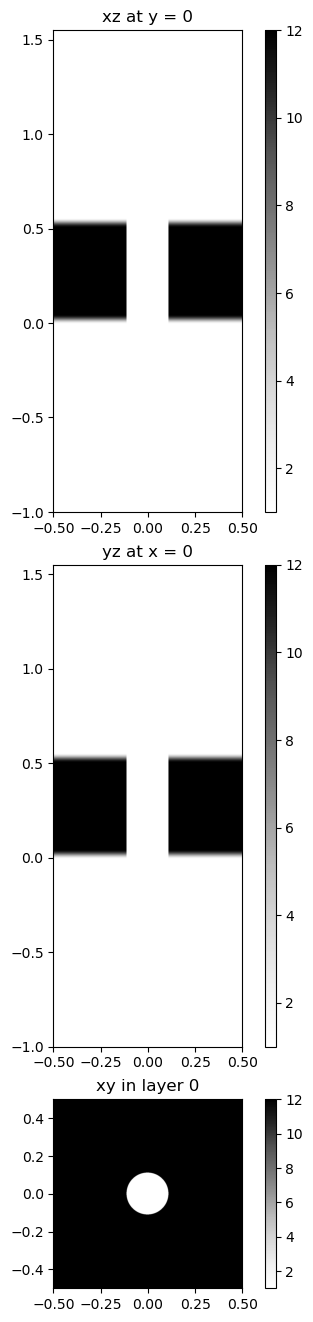

In [42]:
legume.viz.structure(phc, xz=True, yz=True, figsize=3, Ny=1000, Nx=1000)

In [66]:
path = lattice.bz_path(["G", "X", "M", "G"], [40,40,57])
gme.run(kpoints=path["kpoints"], 
        gmode_inds = [0,1,2,3],
        numeig=8, 
        verbose = True)

153.615s total time for real part of frequencies in GuidedModeExp, of which
  11.484s (7%) for guided modes computation using the gmode_compute='exact' method
  0.000s (0%) for inverse matrix of Fourier-space permittivity
  110.435s (72%) for matrix diagionalization using the 'eigh' solver
  31.628s (21%) for creating GME matrix
3.905s  total time for imaginary part of frequencies███████│ 138 of 138


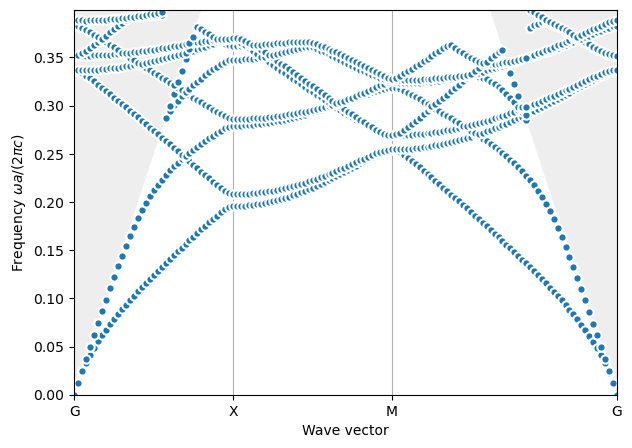

In [67]:
fig, ax = plt.subplots(1, figsize = (7, 5))
legume.viz.bands(gme, figsize=(5,5), k_units=True, Q=False, ax=ax, show_symmetry=True)
ax.set_xticks(path['k_indexes'])
ax.set_xticklabels(path['labels'])
ax.xaxis.grid('True')

In [43]:
gme.freqs

array([[2.40690449e-08, 2.69882751e-08, 3.35927130e-01, ...,
        3.88341901e-01, 3.88341901e-01, 3.94123146e-01],
       [1.22205796e-02, 1.24975838e-02, 3.35343844e-01, ...,
        3.88249888e-01, 3.88356344e-01, 3.94832004e-01],
       [2.31729347e-02, 2.49805308e-02, 3.33431442e-01, ...,
        3.88135099e-01, 3.88399645e-01, 3.96570713e-01],
       ...,
       [2.30186430e-02, 2.47917366e-02, 3.34364051e-01, ...,
        3.86224224e-01, 3.90258084e-01, 3.96309983e-01],
       [1.21319333e-02, 1.24030205e-02, 3.35505814e-01, ...,
        3.87687852e-01, 3.88915985e-01, 3.94794501e-01],
       [2.40690449e-08, 2.69882751e-08, 3.35927130e-01, ...,
        3.88341901e-01, 3.88341901e-01, 3.94123146e-01]], shape=(138, 10))